### Import main functions from Modules, Set file and module paths

In [1]:
from config import settings, get_module

from FormatData import convert_CosMx_to_zarr
from QualityControl import run_qc
from DimensionReduction import run_dimension_reduction
from Annotate import run_annotate
from ViewImages import run_view_images
from SpatialStat import run_spatial_statistics
from MuSpan import run_cosmx_muspan
from MuSpan_SpatialStats import run_muspan_stats
from MuSpan_SpatialGraph import run_muspan_graph

c:\Users\bunga\python\Project2\CosMx\.venv\Lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
c:\Users\bunga\python\Project2\CosMx\.venv\Lib\site-packages\xarray_schema\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
c:\Users\bunga\python\Project2\CosMx\.venv\Lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
c:\Users\bun

In [ ]:
analysis_name = settings["project"]["analysis_name"]
analysis_dir = f"../analysis_{analysis_name}"


# Module names and paths
module_1_name, module_1_dir = get_module(1)
module_2_name, module_2_dir = get_module(2)
module_3_name, module_3_dir = get_module(3)
module_4_name, module_4_dir = get_module(4)
module_5_name, module_5_dir = get_module(5)
module_6_name, module_6_dir = get_module(6)

# Module 0: Format data
dataset_path = settings["io"]["dataset_dir"]
dataset_id = settings["io"]["dataset_id"]
zarr_path = settings["io"]["zarr_dir"]

# Module 1: Quality control
min_counts = settings["modules"]["QualityControl"]["min_counts"]
min_cells = settings["modules"]["QualityControl"]["min_cells"]
min_dapi = settings["modules"]["QualityControl"]["min_dapi"]

# Module 2: Dimension reduction and clustering
n_comps = settings["modules"]["DimensionReduction"]["n_comps"]
n_neighbors = settings["modules"]["DimensionReduction"]["n_neighbors"]
resolution = settings["modules"]["DimensionReduction"]["resolution"]
cluster_name = settings["modules"]["DimensionReduction"]["cluster_name"]

# Module 3: Annotate
new_clusters = settings["modules"]["Annotate"]["new_clusters"]

# Module 4: View images
gene_list = settings["modules"]["ViewImages"]["gene_list"]

# Module 6: MuSpan (Spatial Stats & Graphs)
fov = settings["modules"]["MuSpan"]["fov"]
transcripts = settings["modules"]["MuSpan"]["transcripts"]
muspan_object = f"muspan_object_fov_{fov}.muspan"
cluster_labels = settings["modules"]["MuSpan"]["cluster_labels"]

min_edge_distance = settings["modules"]["MuSpan"]["min_edge_distance"]
max_edge_distance = settings["modules"]["MuSpan"]["max_edge_distance"]
distance_list = settings["modules"]["MuSpan"]["distance_list"]
min_edge_distance_shape = settings["modules"]["MuSpan"]["min_edge_distance_shape"]
max_edge_distance_shape = settings["modules"]["MuSpan"]["max_edge_distance_shape"]
k_list = settings["modules"]["MuSpan"]["k_list"]

### 0. Convert CosMx to Zarr

In [3]:
convert_CosMx_to_zarr(dataset_path, dataset_id, zarr_path)

Reading CosMx data...
INFO     Transposing `data` of type: <class 'dask.array.core.Array'> to ('c', 'y', 'x').                           
INFO     Transposing `data` of type: <class 'dask.array.core.Array'> to ('c', 'y', 'x').                           
INFO     Transposing `data` of type: <class 'dask.array.core.Array'> to ('c', 'y', 'x').                           
INFO     Transposing `data` of type: <class 'dask.array.core.Array'> to ('c', 'y', 'x').                           
INFO     Transposing `data` of type: <class 'dask.array.core.Array'> to ('c', 'y', 'x').                           
INFO     Transposing `data` of type: <class 'dask.array.core.Array'> to ('c', 'y', 'x').                           
INFO     Transposing `data` of type: <class 'dask.array.core.Array'> to ('c', 'y', 'x').                           
INFO     Transposing `data` of type: <class 'dask.array.core.Array'> to ('c', 'y', 'x').                           
INFO     Transposing `data` of type: <class 'dask.

### 1. Quality Control

In [4]:
run_qc(module_1_dir, zarr_path, min_counts, min_cells, min_dapi)

INFO:ome_zarr.reader:root_attr: multiscales
INFO:ome_zarr.reader:root_attr: omero
INFO:ome_zarr.reader:root_attr: spatialdata_attrs
INFO:ome_zarr.reader:datasets [{'coordinateTransformations': [{'scale': [1.0, 1.0, 1.0], 'type': 'scale'}], 'path': '0'}]
INFO:ome_zarr.reader:resolution: 0
INFO:ome_zarr.reader: - shape ('c', 'y', 'x') = (3, 4256, 4256)
INFO:ome_zarr.reader: - chunks =  ['3', '4256', '4256']
INFO:ome_zarr.reader: - dtype = uint8
INFO:ome_zarr.reader:root_attr: multiscales
INFO:ome_zarr.reader:root_attr: omero
INFO:ome_zarr.reader:root_attr: spatialdata_attrs
INFO:ome_zarr.reader:root_attr: multiscales
INFO:ome_zarr.reader:root_attr: omero
INFO:ome_zarr.reader:root_attr: spatialdata_attrs
INFO:ome_zarr.reader:datasets [{'coordinateTransformations': [{'scale': [1.0, 1.0, 1.0], 'type': 'scale'}], 'path': '0'}]
INFO:ome_zarr.reader:resolution: 0
INFO:ome_zarr.reader: - shape ('c', 'y', 'x') = (3, 4256, 4256)
INFO:ome_zarr.reader: - chunks =  ['3', '4256', '4256']
INFO:ome_zar

printing adata obs collumns-----
Index(['fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.Histone',
       'Max.Histone', 'Mean.G', 'Max.G', 'Mean.rRNA', 'Max.rRNA', 'Mean.GFAP',
       'Max.GFAP', 'Mean.DAPI', 'Max.DAPI', 'fov_labels', 'cell_ID'],
      dtype='object')
Negative DNA probe count % : 0.0000%
Negative decoding count % : 0.0000%
Average number of transcripts per cell: 1741.85
Average unique transcripts per cell: 378.21
Max cell area: 51773
Min cell area: 500
Saved plots to c:\Users\bunga\python\Project2\CosMx\Spatial-Transcriptomics-CosMx-Xenium\Modules\..\analysis_Kitam\1_QualityControl\cell_summary_histograms.png
Filtering cells and genes...
Normalize data...
Data saved to ..\analysis_Kitam\1_QualityControl\adata.h5ad
Quality control completed successfully.


### 2. Dimension Reduction

Loading CosMx data...
Compute PCA...
PCA Variance plot saved to ..\analysis_Kitam\2_DimensionReduction
Compute neighbors...
Create UMAPs and cluster cells..
Plotting UMAPs...
UMAP plot saved to ..\analysis_Kitam\2_DimensionReduction
Plotting leiden clusters...
leiden spatial scatter plot saved to ..\analysis_Kitam\2_DimensionReduction
Data saved to ..\analysis_Kitam\2_DimensionReduction\adata.h5ad


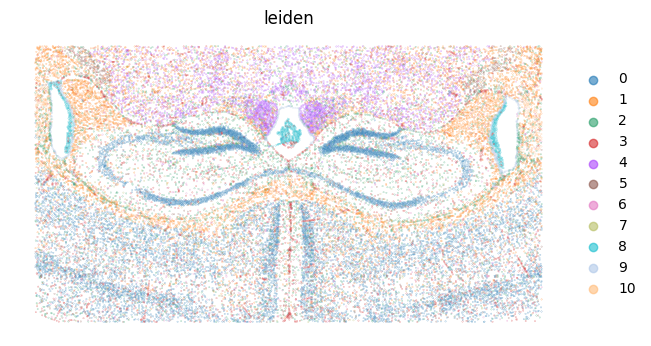

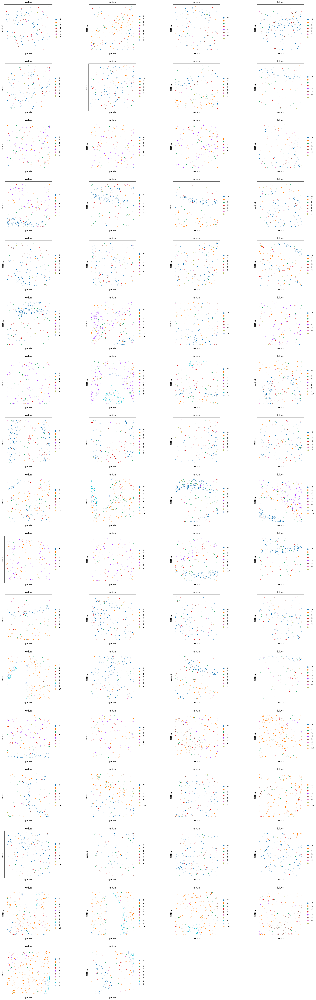

In [5]:
run_dimension_reduction(
    module_1_dir,
    module_2_dir,
    module_2_name,
    n_comps,
    n_neighbors,
    resolution,
    cluster_name,
)

### 3. Annotate

In [6]:
run_annotate(module_3_dir, module_3_name, cluster_name, new_clusters, module_2_dir)

Loading CosMx data...
Calculating differentially expressed genes for each cluster...
Plotting the top differentially expressed genes for each cluster...
Dotplot saved to ..\analysis_Kitam\3_Annotate
Plot differentially expressed genes for each cluster in elbow plot...
UMAP plot saved to ..\analysis_Kitam\3_Annotate
Save files for differentially expressed genes for each cluster...
File 1...


... storing 'cell_type' as categorical


Markers saved to ..\analysis_Kitam\3_Annotate
File 2...
Top differentially expressed genes saved to ..\analysis_Kitam\3_Annotate
File 3...
Exported cluster 0 data to ..\analysis_Kitam\3_Annotate\cluster_diff_genes\cluster_0_data.csv
Exported cluster 1 data to ..\analysis_Kitam\3_Annotate\cluster_diff_genes\cluster_1_data.csv
Exported cluster 2 data to ..\analysis_Kitam\3_Annotate\cluster_diff_genes\cluster_2_data.csv
Exported cluster 3 data to ..\analysis_Kitam\3_Annotate\cluster_diff_genes\cluster_3_data.csv
Exported cluster 4 data to ..\analysis_Kitam\3_Annotate\cluster_diff_genes\cluster_4_data.csv
Exported cluster 5 data to ..\analysis_Kitam\3_Annotate\cluster_diff_genes\cluster_5_data.csv
Exported cluster 6 data to ..\analysis_Kitam\3_Annotate\cluster_diff_genes\cluster_6_data.csv
Exported cluster 7 data to ..\analysis_Kitam\3_Annotate\cluster_diff_genes\cluster_7_data.csv
Exported cluster 8 data to ..\analysis_Kitam\3_Annotate\cluster_diff_genes\cluster_8_data.csv
Exported cluste

### 4. View Images

Loading Xenium data...
Visualize clusters on tissue...
Saved leiden clusters plot to ..\analysis_Kitam\4_ViewImages\leiden_clusters.png
Plotting genes of interest on tissue...
Saved gene expression plot to ..\analysis_Kitam\4_ViewImages\gene_expression.png
Data saved to ..\analysis_Kitam\4_ViewImages\adata.h5ad
Imaging module completed successfully.


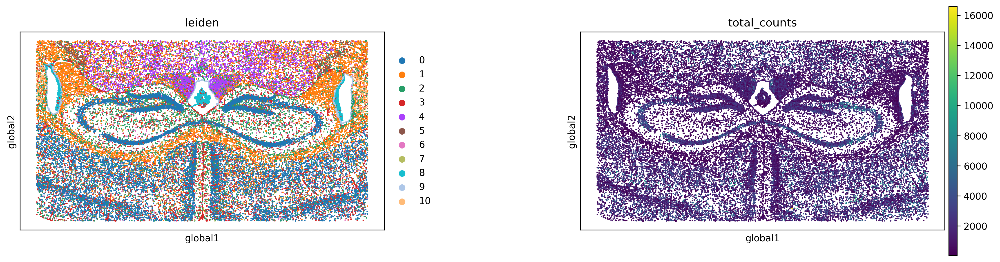

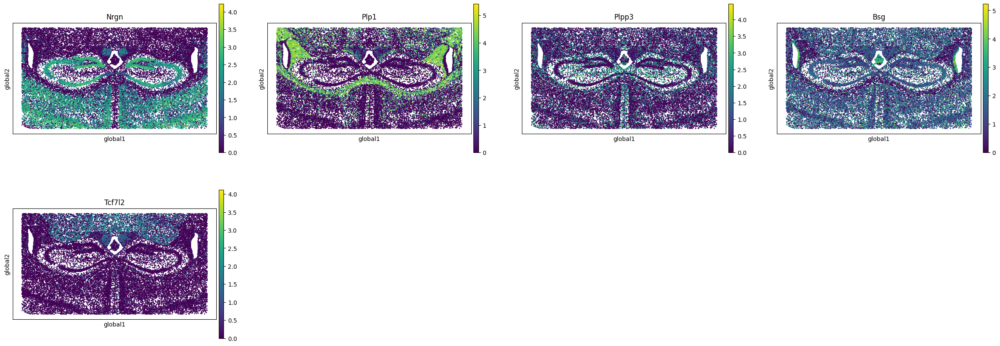

In [7]:
run_view_images(module_3_dir, module_4_dir, module_4_name, gene_list)

### 5. Spatial Stats (SquidPy)

Loading Xenium data...
Building spatial neighborhood graph...
Computing and plotting centrality scores...


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

Centrality scores plot saved to ..\analysis_Kitam\5_SpatialStat\centrality_scores.png
Computing co-occurrence probability...


100%|██████████| 1/1 [01:41<00:00, 101.86s/]


Co-occurrence plot saved to ..\analysis_Kitam\5_SpatialStat\co_occurrence.png
Performing neighborhood enrichment analysis...


100%|██████████| 1000/1000 [00:14<00:00, 66.95/s]


Neighborhood enrichment plot saved to ..\analysis_Kitam\5_SpatialStat\nhood_enrichment.png
Calculating Moran's I...


100%|██████████| 100/100 [00:22<00:00,  4.54/s]


Moran's I results saved to ..\analysis_Kitam\5_SpatialStat\moranI_results.csv
Data saved to ..\analysis_Kitam\5_SpatialStat\adata.h5ad
Spatial statistics module completed successfully.


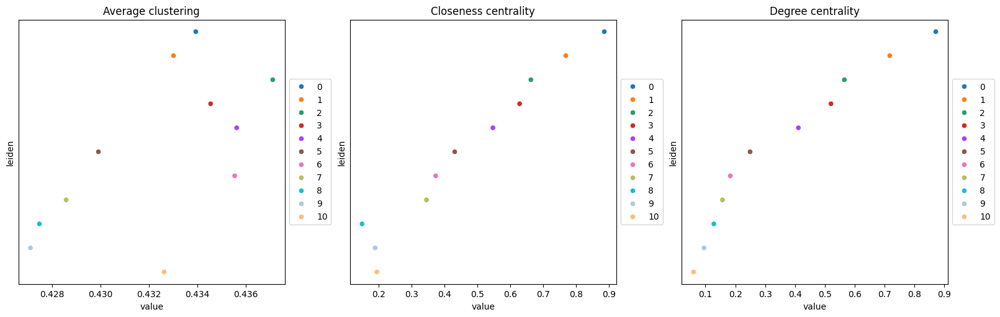

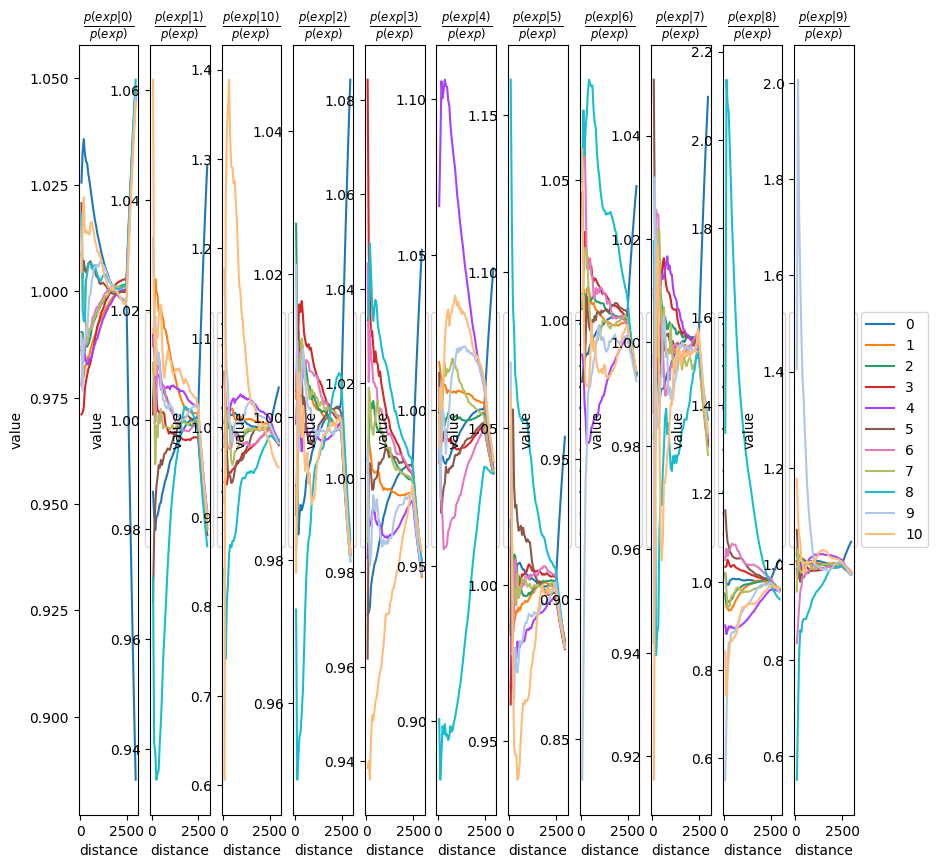

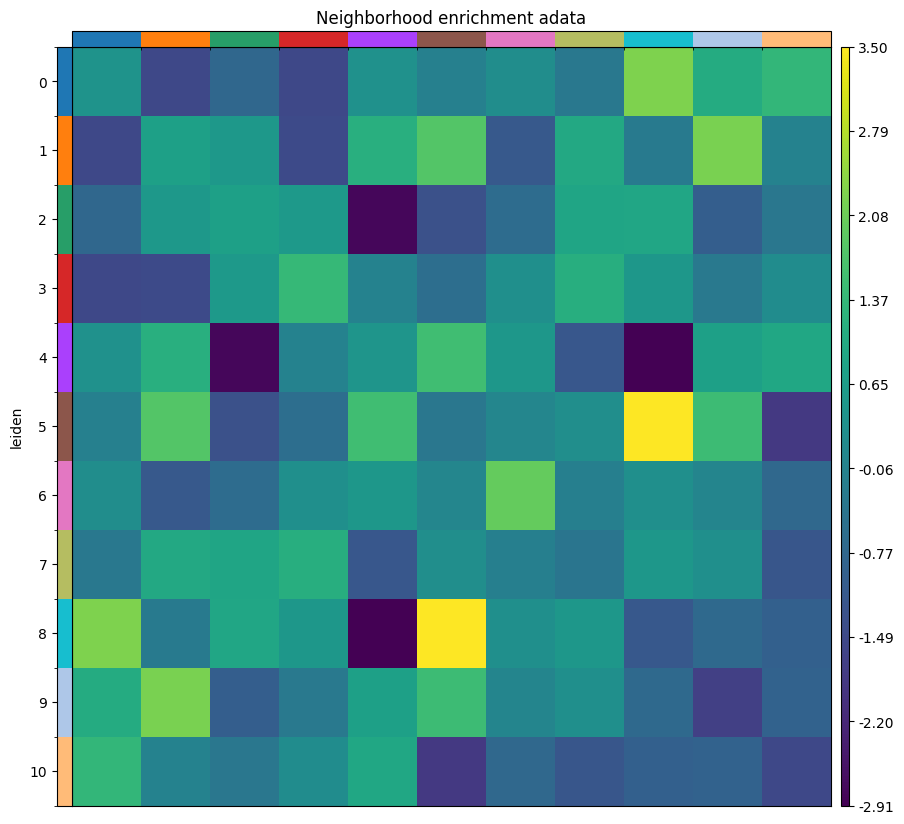

In [8]:
run_spatial_statistics(module_5_dir, module_5_name, module_4_dir)

### 6. MuSpan Analysis (Spatial stats and graph)

INFO:MuSpan:Loading CosMx SpatialData and Annotated AnnData...
INFO:ome_zarr.reader:root_attr: multiscales
INFO:ome_zarr.reader:root_attr: omero
INFO:ome_zarr.reader:root_attr: spatialdata_attrs
INFO:ome_zarr.reader:datasets [{'coordinateTransformations': [{'scale': [1.0, 1.0, 1.0], 'type': 'scale'}], 'path': '0'}]
INFO:ome_zarr.reader:resolution: 0
INFO:ome_zarr.reader: - shape ('c', 'y', 'x') = (3, 4256, 4256)
INFO:ome_zarr.reader: - chunks =  ['3', '4256', '4256']
INFO:ome_zarr.reader: - dtype = uint8
INFO:ome_zarr.reader:root_attr: multiscales
INFO:ome_zarr.reader:root_attr: omero
INFO:ome_zarr.reader:root_attr: spatialdata_attrs
INFO:ome_zarr.reader:root_attr: multiscales
INFO:ome_zarr.reader:root_attr: omero
INFO:ome_zarr.reader:root_attr: spatialdata_attrs
INFO:ome_zarr.reader:datasets [{'coordinateTransformations': [{'scale': [1.0, 1.0, 1.0], 'type': 'scale'}], 'path': '0'}]
INFO:ome_zarr.reader:resolution: 0
INFO:ome_zarr.reader: - shape ('c', 'y', 'x') = (3, 4256, 4256)
INFO:

Domain muspan_object_fov_32 saved successfully to ..\analysis_Kitam\6_MuSpan.
Loading MuSpAn object...
MuSpAn domain loaded successfully. Domain summary:
Domain name: CosMx_FOV_32
Number of objects: 26762
Collections: ['Transcripts', 'Cell centroids', 'Cell boundaries']
Labels: ['Transcript ID', 'Cell ID', 'cell_type'] 
Networks: [] 
Distance matrices: []
Found 10 unique cell types.
Calculating pairwise cross-PCF for selected cell types...
['Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_3', 'Cluster_4', 'Cluster_6', 'Cluster_7', 'Cluster_8', 'Cluster_9', 'Filtered_in_QC']
Calculating cross-PCF for Cluster_0 and Cluster_1...
Cross-PCF plot saved at ..\analysis_Kitam\6_MuSpan\cross_pair_correlation_function_Cluster_0_Cluster_1.png
Visualization saved at ..\analysis_Kitam\6_MuSpan\visualize_Cluster_0_Cluster_1.png
Calculating pairwise cross-PCF for all cell types...
Calculating cross-PCF: Cluster_0 vs Cluster_1
Calculating cross-PCF: Cluster_0 vs Cluster_2
Calculating cross-PCF: Cluster_

INFO:MuSpan_SpatialGraph:Loading MuSpAn object...


Cross-PCF matrix plot saved at ..\analysis_Kitam\6_MuSpan\cross_pair_correlation_function_all.png


INFO:MuSpan_SpatialGraph:Creating Delaunay triangulation spatial graph...
INFO:MuSpan_SpatialGraph:Plotting filtered and unfiltered Delaunay networks...


MuSpAn domain loaded successfully. Domain summary:
Domain name: CosMx_FOV_32
Number of objects: 26762
Collections: ['Transcripts', 'Cell centroids', 'Cell boundaries']
Labels: ['Transcript ID', 'Cell ID', 'cell_type'] 
Networks: [] 
Distance matrices: []


INFO:MuSpan_SpatialGraph:Delaunay networks plotted and saved
INFO:MuSpan_SpatialGraph:Creating Proximity based networks (point-like objects)...
INFO:MuSpan_SpatialGraph:Plotting Proximity networks (point-like objects)...
INFO:MuSpan_SpatialGraph:Proximity networks (point-like objects) plotted and saved
INFO:MuSpan_SpatialGraph:Creating Proximity based networks (shape-like objects)...
INFO:MuSpan_SpatialGraph:Plotting Proximity networks (shape-like objects)...
INFO:MuSpan_SpatialGraph:Proximity networks (shape-like objects) plotted and saved
INFO:MuSpan_SpatialGraph:Creating KNN based networks ...
INFO:MuSpan_SpatialGraph:Plotting KNN based networks...
INFO:MuSpan_SpatialGraph:KNN networks plotted and saved
INFO:MuSpan_SpatialGraph:Networks in domain: dict_keys(['Delaunay CC unfiltered', 'Delaunay CC filtered', 'prox network centroids 50', 'prox network centroids 90', 'prox network centroids 120', 'Contact network', '2-NN network', '5-NN network', '10-NN network', '15-NN network'])
INFO

Domain muspan_object saved successfully to ..\analysis_Kitam\6_MuSpan.


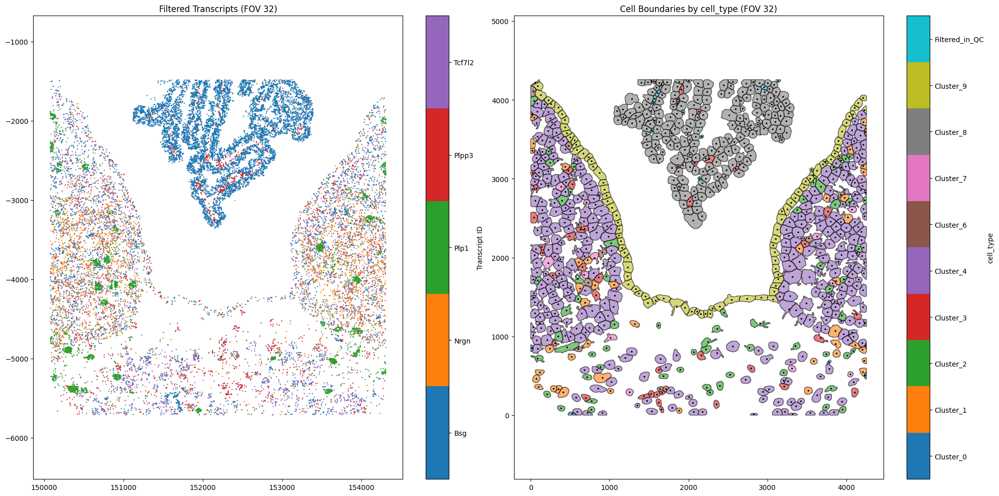

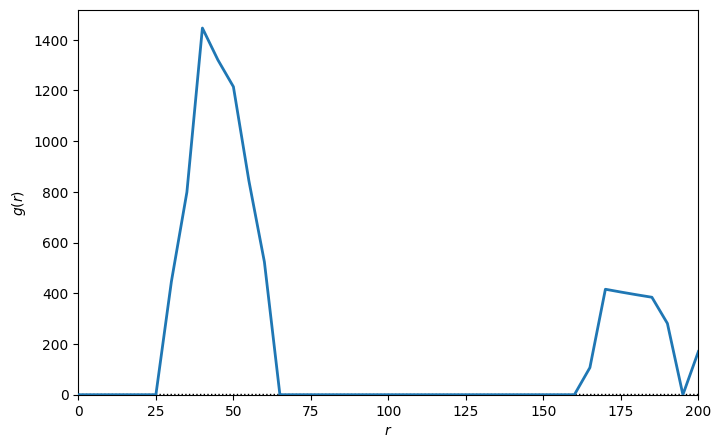

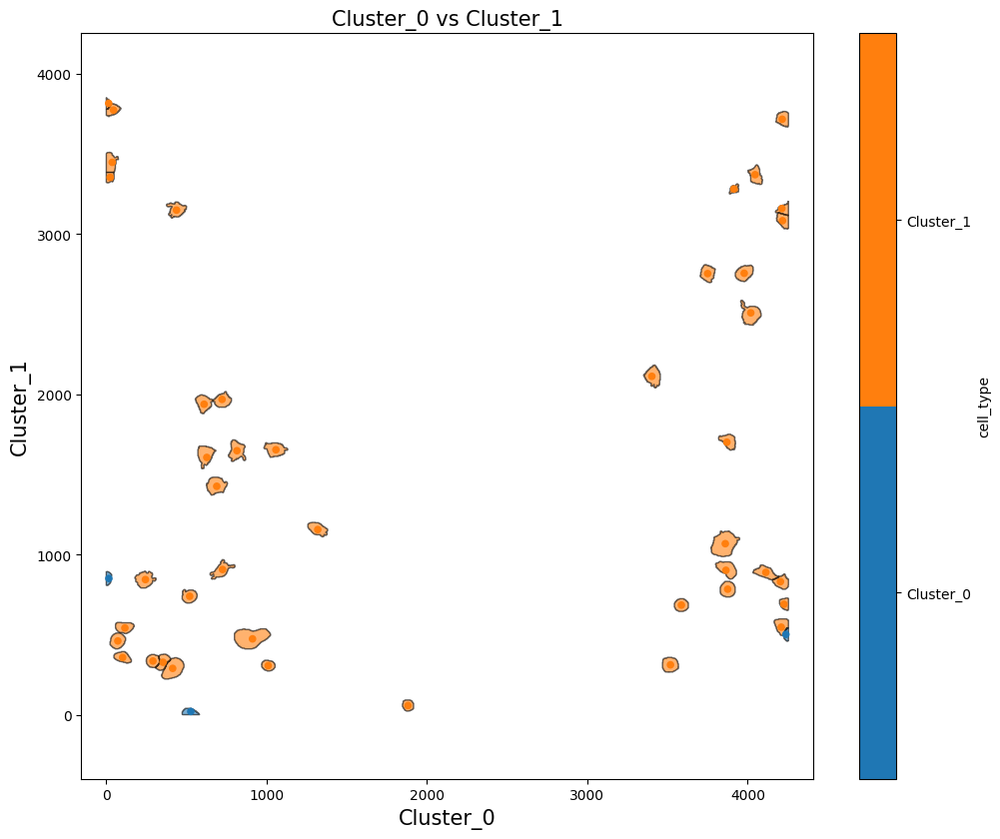

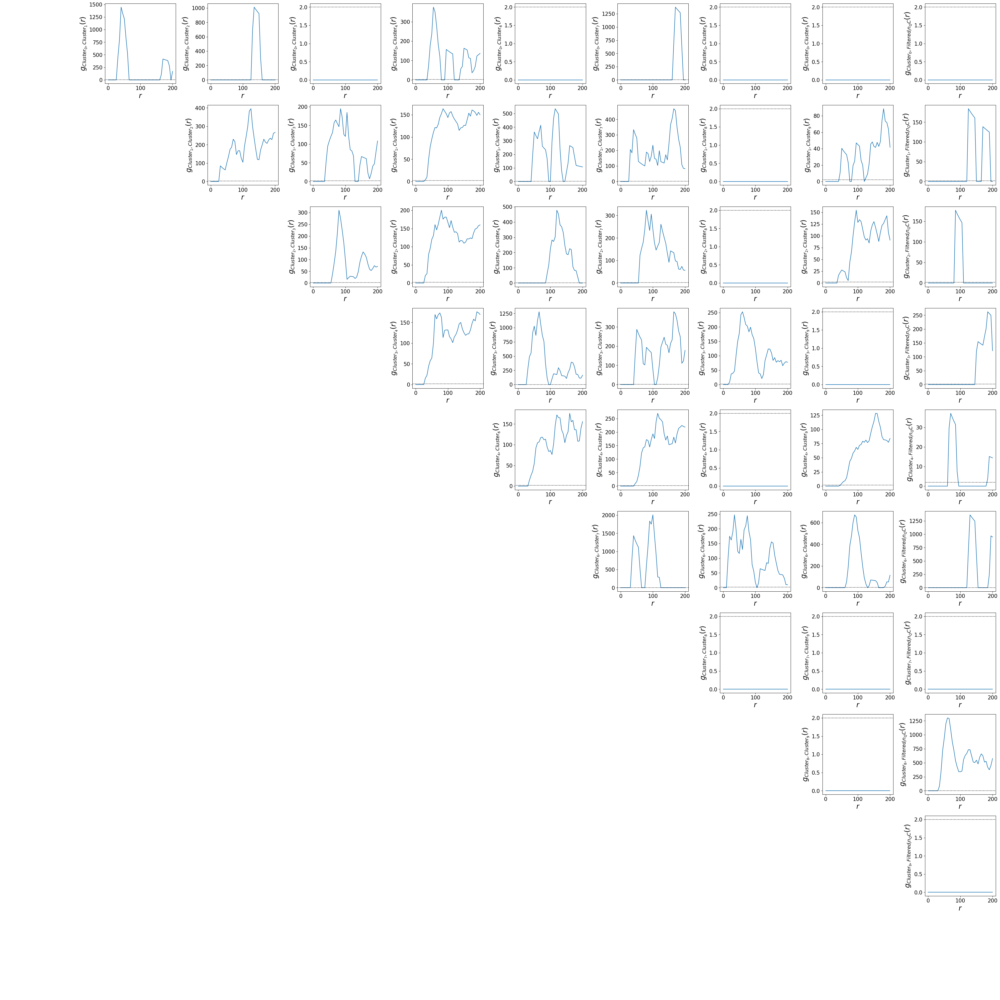

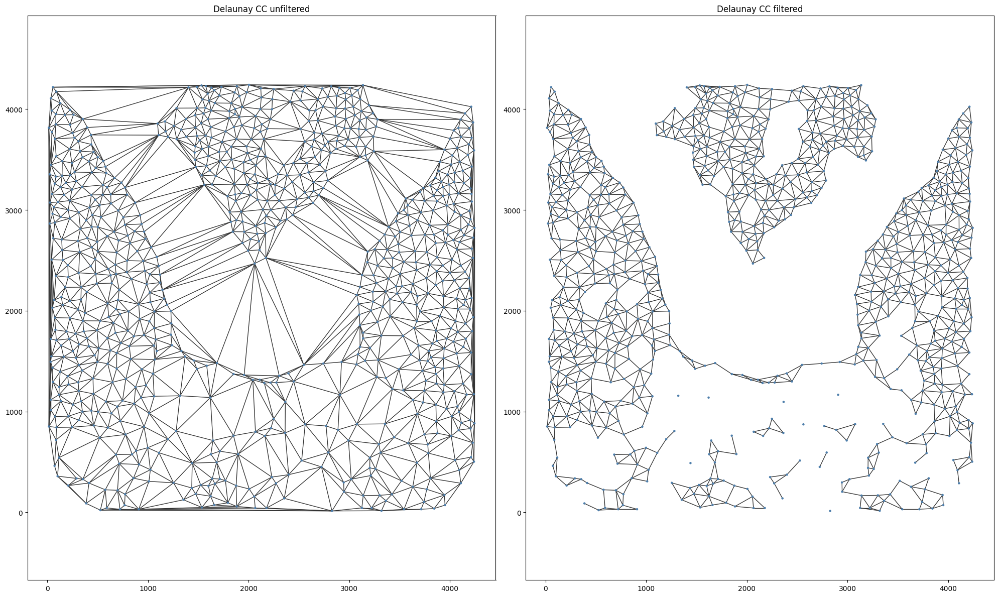

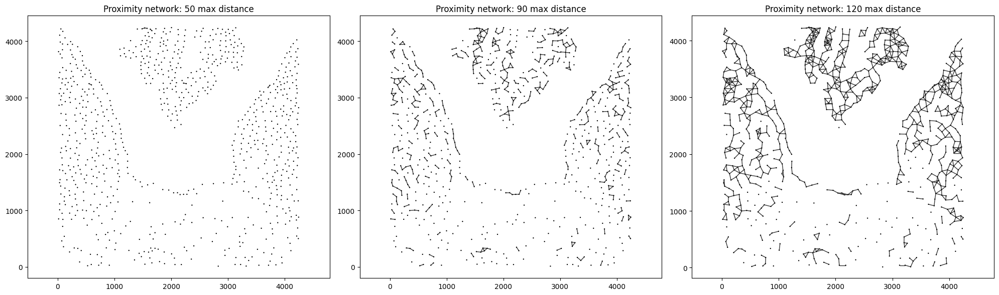

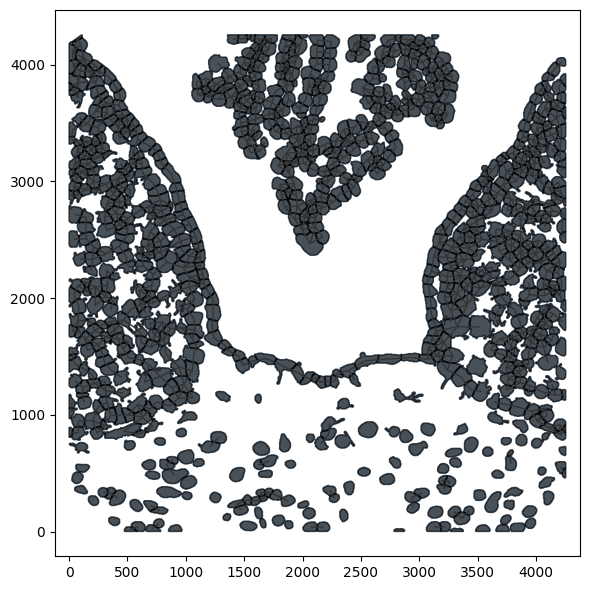

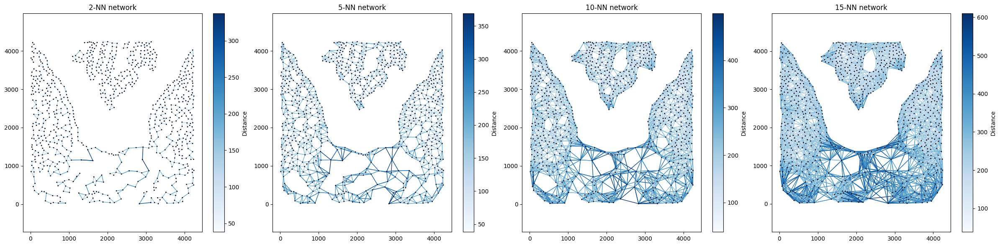

In [9]:
run_cosmx_muspan(
    zarr_path=zarr_path,
    flat_files_dir=dataset_path,
    fov_id=fov,
    module_5_dir=module_5_dir,
    module_dir=module_6_dir,
    cluster_labels=cluster_labels,
    transcripts_to_keep=transcripts,
)

run_muspan_stats(module_6_dir, muspan_object, cluster_labels)
run_muspan_graph(
    module_6_dir,
    muspan_object,
    min_edge_distance,
    max_edge_distance,
    distance_list,
    min_edge_distance_shape,
    max_edge_distance_shape,
    k_list,
)